<a href="https://colab.research.google.com/github/madan-genai/Blog_Writing_Agent/blob/main/basic_Blog_writing_agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install langchain_groq langchain_core

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.0 MB/s eta 0:00:00


In [ ]:
import os
os.environ["GROQ_API_KEY"]=""

In [ ]:
from __future__ import annotations
import operator
from typing import List, TypedDict, Annotated
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage , HumanMessage

In [ ]:
class Task(BaseModel):
  id: int
  title: str
  brief :str = Field(...,description="what to cover")

In [ ]:
class Plan(Task):
  blog_title :str
  tasks : List[Task]

In [ ]:
class State(TypedDict):
  topic : str
  plan : Plan
  sections : Annotated[list[str], operator.add]
  final :str

In [ ]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [ ]:
def orchestrator(state: State) -> dict:

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

In [ ]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

In [ ]:
def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [ ]:
from pathlib import Path

def reducer(state: State) -> dict:

    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

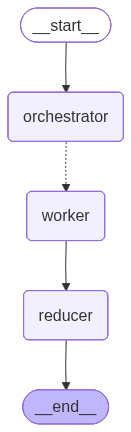

In [ ]:
g = StateGraph(State)
g.add_node("orchestrator",orchestrator)
g.add_node("worker",worker)
g.add_node("reducer", reducer)

g.add_edge(START,"orchestrator")
g.add_conditional_edges("orchestrator",fanout,["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer",END)

app = g.compile()
app

In [ ]:
result = app.invoke({"topic": "Write a blog on Self Attention", "sections": []})

In [ ]:
result

{'topic': 'Write a blog on Self Attention',
 'plan': Plan(id=1, title='Understanding Self Attention', brief='Introduction to self attention and its importance in deep learning', blog_title='The Power of Self Attention in Deep Learning', tasks=[Task(id=1, title='Introduction', brief='Define self attention and its role in deep learning models'), Task(id=2, title='Mechanics of Self Attention', brief='Explain the mathematical formulation of self attention'), Task(id=3, title='Types of Self Attention', brief='Discuss different variants of self attention, such as local and global self attention'), Task(id=4, title='Applications of Self Attention', brief='Explore the use of self attention in various deep learning applications, such as natural language processing and computer vision'), Task(id=5, title='Benefits and Limitations', brief='Discuss the benefits and limitations of using self attention in deep learning models'), Task(id=6, title='Real-World Examples', brief='Provide real-world examp